# Apple Stock Price Prediction with Linear Regression

This notebook builds a simple next-day stock price prediction model using a sliding window of the previous 5 trading days. It uses Apple daily data, trains a Linear Regression model, evaluates it, and plots actual vs predicted values on the test set.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
# Load the cleaned Apple daily stock data
df = pd.read_csv('APPLE_daily_reformed.csv')

# Convert Date to datetime and sort in chronological order
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

# Make sure the price and volume columns are numeric
numeric_columns = ['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors='coerce')

# Drop rows with missing values after conversion
df = df.dropna().reset_index(drop=True)

print('Rows loaded:', len(df))
df.head()

Rows loaded: 6638


,Date,Open,High,Low,Close,Volume,Adj Close
0,2000-01-03,0.784869,0.841934,0.761015,0.837724,535796800,0.837724
1,2000-01-04,0.810128,0.827902,0.757273,0.767096,512377600,0.767096
2,2000-01-05,0.776450,0.827434,0.770837,0.778321,778321600,0.778321
3,2000-01-06,0.794225,0.800773,0.710966,0.710966,767972800,0.710966
4,2000-01-07,0.722192,0.755870,0.714709,0.744644,460734400,0.744644


In [4]:
# Set the sliding window size
WINDOW_SIZE = 5

# We use these five features from each day in the window
feature_columns = ['Open', 'High', 'Low', 'Close', 'Volume']

# Lists to store the model inputs, targets, and dates for the target day
X = []
y = []
target_dates = []

# Each training example uses the previous 5 days to predict the next day's Close price
for i in range(WINDOW_SIZE, len(df)):
    window = df.iloc[i - WINDOW_SIZE:i][feature_columns].values
    X.append(window.flatten())
    y.append(df.iloc[i]['Close'])
    target_dates.append(df.iloc[i]['Date'])

# Convert lists to numpy arrays for scikit-learn
X = np.array(X)
y = np.array(y)
target_dates = np.array(target_dates)

print('Feature matrix shape:', X.shape)
print('Target vector shape:', y.shape)

Feature matrix shape: (6633, 25)
Target vector shape: (6633,)


In [5]:
# Split the data chronologically: first 80% for training, last 20% for testing
split_index = int(len(X) * 0.8)

X_train = X[:split_index]
X_test = X[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]
dates_test = target_dates[split_index:]

print('Training samples:', len(X_train))
print('Testing samples:', len(X_test))

Training samples: 5306
Testing samples: 1327


In [6]:
# Train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
predictions = model.predict(X_test)

predictions[:5]

array([131.91652294, 131.68875894, 132.29410157, 129.65371692,
       127.73735005])

In [7]:
# Evaluate the model using common regression metrics
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f'MAE:  {mae:.4f}')
print(f'RMSE: {rmse:.4f}')
print(f'R^2:  {r2:.4f}')

MAE:  2.3802
RMSE: 3.3553
R^2:  0.9944


In [8]:
# Show the first 10 predictions compared to the actual values
results_df = pd.DataFrame({
    'Date': dates_test,
    'Actual Close': y_test,
    'Predicted Close': predictions
})

results_df.head(10)

,Date,Actual Close,Predicted Close
0,2021-02-11,131.494873,131.916523
1,2021-02-12,131.728424,131.688759
2,2021-02-16,129.607056,132.294102
3,2021-02-17,127.320267,129.653717
4,2021-02-18,126.220673,127.737350
5,2021-02-19,126.376328,125.864862
6,2021-02-22,122.610458,126.362911
7,2021-02-23,122.474243,123.570412
8,2021-02-24,121.977959,120.637578
9,2021-02-25,117.735237,120.145476


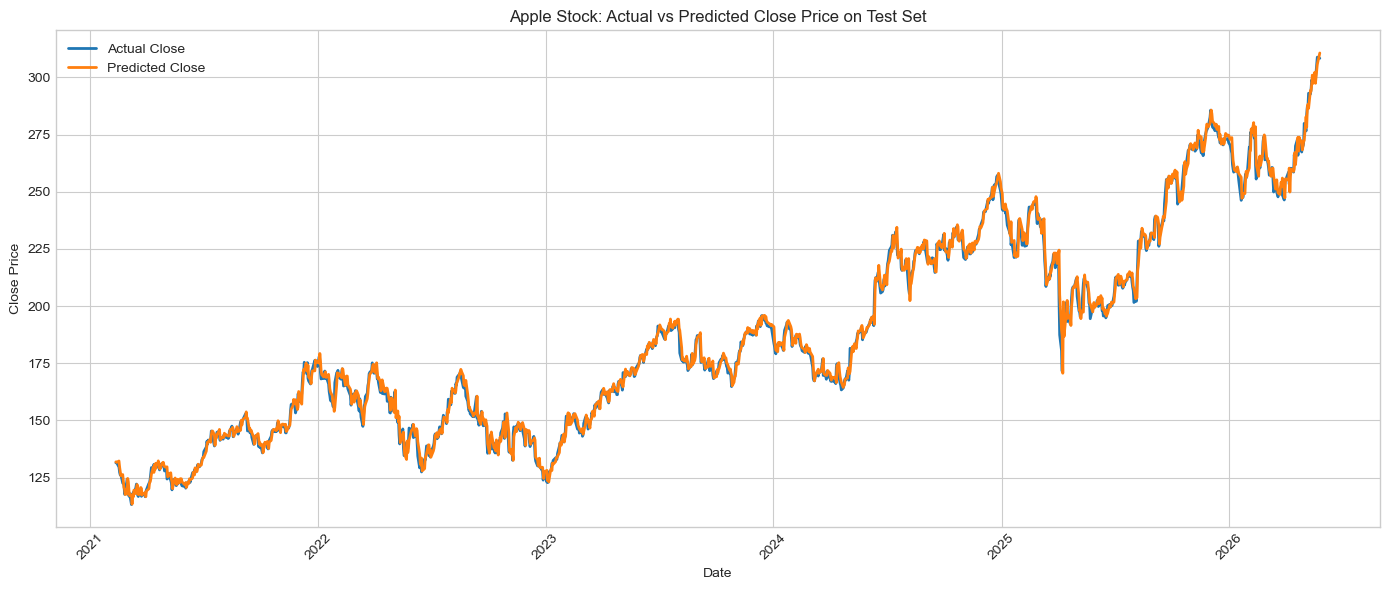

In [9]:
# Plot actual vs predicted Close prices on the test set
plt.figure(figsize=(14, 6))
plt.plot(dates_test, y_test, label='Actual Close', linewidth=2)
plt.plot(dates_test, predictions, label='Predicted Close', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Apple Stock: Actual vs Predicted Close Price on Test Set')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Notes
- The model uses the previous 5 trading days to predict the next day's Close price.
- The split is chronological, so the model is tested on future data it has not seen during training.
- If you want to experiment, try changing `WINDOW_SIZE` to 10, 20, or 30 and compare the metrics.